In [44]:
from functools import reduce
import os
import re 
import time

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import neural_network

## Data Pre-Processing

In [45]:
DATA_DIR = 'data/ml-1m'
DATA_DIR_20ML = 'data/ml-20m' # for tags

In [46]:
movies_pd = pd.read_csv(os.path.join(DATA_DIR, 'movies.dat'),
                        sep='::',
                        names=['mid', 'mName', 'mGenders'],
                        engine='python', encoding='latin-1')


display(movies_pd.head())

,mid,mName,mGenders
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [47]:
mid = 10
display(movies_pd[movies_pd.mid == mid])

name = 'Machine'
display(movies_pd[movies_pd.mName.str.contains(name,
                                               regex=False, case=False)])

,mid,mName,mGenders
9,10,GoldenEye (1995),Action|Adventure|Thriller


,mid,mName,mGenders
1409,1433,"Machine, The (1994)",Comedy|Horror


In [48]:
ratings_pd = pd.read_csv(os.path.join(DATA_DIR, 'ratings.dat'),
                         sep='::',
                         names=['uid', 'mid', 'rating', 'timestamp'],
                         parse_dates=['timestamp'],
                         engine='python')

C:\Users\mbouhsen\AppData\Local\Temp\ipykernel_20188\4280596834.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ratings_pd = pd.read_csv(os.path.join(DATA_DIR, 'ratings.dat'),


In [49]:
display(ratings_pd.head())

,uid,mid,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [50]:
print(f"""The dataset contains {ratings_pd.shape[0]} ratings,
      from {ratings_pd.uid.nunique()} users,
      and {ratings_pd.mid.nunique()} items.""")

The dataset contains 1000209 ratings,
      from 6040 users,
      and 3706 items.


In [51]:
users_pd = pd.read_csv(os.path.join(DATA_DIR, 'users.dat'),
                       sep='::',
                       names=['uid', 'gender', 'age', 'occupation', 'zip'],
                       engine='python')

display(users_pd.head())

,uid,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [52]:
print(f'This table contains {users_pd.shape[0]} users')

This table contains 6040 users


In [53]:
print(f'We originally have {users_pd.zip.nunique()} different zip code')
users_pd['zip'] = users_pd['zip'].apply(lambda x : x[:2])
display(users_pd['zip'].head())
print(f'By only keep the first two digits of each zip code, \
we reduced the unique number of zip codes to {users_pd.zip.nunique()}.')

We originally have 3439 different zip code


0    48
1    70
2    55
3    02
4    55
Name: zip, dtype: str

By only keep the first two digits of each zip code, we reduced the unique number of zip codes to 100.


In [54]:
tags_scores = pd.read_csv(os.path.join(DATA_DIR_20ML, 'genome-scores.csv.gz'),
                          skiprows=1,
                          names=['mid', 'tid', 'relevance'])

display(tags_scores.head(10))

,mid,tid,relevance
0,1,1,0.02500
1,1,2,0.02500
2,1,3,0.05775
3,1,4,0.09675
4,1,5,0.14675
5,1,6,0.21700
6,1,7,0.06700
7,1,8,0.26275
8,1,9,0.26200
9,1,10,0.03200


In [55]:
print(f'The data contains {tags_scores.tid.nunique()} unique tags.')
print(f'Affinitiees are contained in : {tags_scores.relevance.min()}--{tags_scores.relevance.max().round(3)}')
display(tags_scores.relevance.describe())

The data contains 1128 unique tags.
Affinitiees are contained in : 0.0002499999999999--1.0


count    1.170977e+07
mean     1.164833e-01
std      1.542463e-01
min      2.500000e-04
25%      2.425000e-02
50%      5.650000e-02
75%      1.415000e-01
max      1.000000e+00
Name: relevance, dtype: float64

In [56]:
tags_names = pd.read_csv(os.path.join(DATA_DIR_20ML, 'genome-tags.csv'),
                        skiprows=1,
                        names=['tid', 'tName'])
display(tags_names.head(10))

,tid,tName
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s
5,6,1950s
6,7,1960s
7,8,1970s
8,9,1980s
9,10,19th century


In [57]:
tags_scores = tags_scores.loc[tags_scores['mid'].isin(ratings_pd['mid'].unique())]
print(tags_scores.mid.nunique())

3470


In [58]:
print('unique tags: ', tags_scores['tid'].nunique())
tags_scores_high = tags_scores.loc[tags_scores['relevance'] > 0.9]
print('unique tags with relevance > 0.9: ', tags_scores_high['tid'].nunique())

unique tags:  1128
unique tags with relevance > 0.9:  968


In [59]:
tags_high_names_movies = pd.merge(tags_scores_high, tags_names, on='tid', how='inner')
tags_high_names_movies = pd.merge(tags_high_names_movies, movies_pd, on='mid', how='inner')
display(tags_high_names_movies.head())

,mid,tid,relevance,tName,mName,mGenders
0,1,63,0.93325,animated,Toy Story (1995),Animation|Children's|Comedy
1,1,64,0.98575,animation,Toy Story (1995),Animation|Children's|Comedy
2,1,186,0.95650,cartoon,Toy Story (1995),Animation|Children's|Comedy
3,1,203,0.92625,childhood,Toy Story (1995),Animation|Children's|Comedy
4,1,204,0.96425,children,Toy Story (1995),Animation|Children's|Comedy


In [60]:
tags = 'scary'
display(tags_high_names_movies[tags_high_names_movies.tName.str.contains(tags, regex=False, case=False)])

,mid,tid,relevance,tName,mName,mGenders
4435,1200,882,0.90475,scary,Aliens (1986),Action|Sci-Fi|Thriller|War
4645,1214,882,0.93875,scary,Alien (1979),Action|Horror|Sci-Fi|Thriller
5146,1258,882,0.91675,scary,"Shining, The (1980)",Horror
5613,1321,882,0.93475,scary,"American Werewolf in London, An (1981)",Horror
5671,1342,882,0.96625,scary,Candyman (1992),Horror
5698,1347,882,0.96550,scary,"Nightmare on Elm Street, A (1984)",Horror
5714,1350,882,0.94675,scary,"Omen, The (1976)",Horror
5891,1387,882,0.94250,scary,Jaws (1975),Action|Horror
6445,1590,882,0.93525,scary,Event Horizon (1997),Action|Mystery|Sci-Fi|Thriller
7872,1974,882,0.94625,scary,Friday the 13th (1980),Horror


In [61]:
tags_scores_high_dum = pd.get_dummies(tags_scores_high, columns=['tid'])
tags_scores_high_dum = tags_scores_high_dum.reset_index()
display(tags_scores_high_dum.head())
tags_per_movie = tags_scores_high_dum.groupby('mid').sum()

,index,mid,relevance,tid_1,tid_2,tid_3,tid_5,tid_6,tid_7,tid_9,...,tid_1119,tid_1120,tid_1121,tid_1122,tid_1123,tid_1124,tid_1125,tid_1126,tid_1127,tid_1128
0,62,1,0.93325,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,63,1,0.98575,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,185,1,0.95650,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,202,1,0.92625,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,203,1,0.96425,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Text(0.5, 1.0, 'Histogram of Movies per tag')

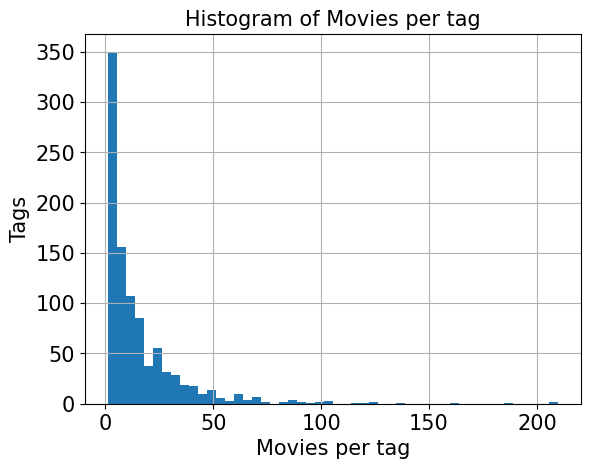

In [62]:
th = tags_scores_high.groupby("tid").count()
hists = th.hist(bins=50, column="mid", xlabelsize=15, ylabelsize=15)[0][0]
hists.set_ylabel("Tags", size=15)
hists.set_xlabel("Movies per tag", size=15)
hists.set_title("Histogram of Movies per tag", size=15)

In [87]:
th

,mid,relevance
tid,,
1,16,16
2,17,17
3,21,21
5,19,19
6,2,2
...,...,...
1124,1,1
1125,3,3
1126,31,31


In [100]:
tname = tags_names.at[tags_names.tid.eq(th.mid.idxmax()).idxmax(), 'tName']
print(f'The most popular tag is "{tname}" with {th.mid.max()} movies.')

The most popular tag is "comedy" with 210 movies.


Text(0.5, 1.0, 'Histogram of Tags per movie')

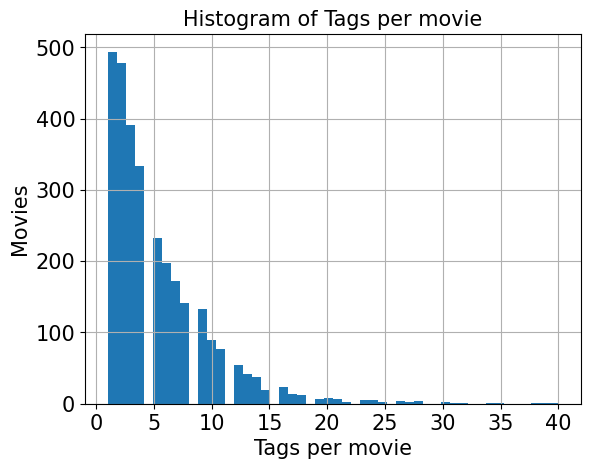

In [106]:
hists = tags_scores_high.groupby('mid').count().hist(bins=50, column='tid', xlabelsize=15, ylabelsize=15)
hists[0][0].set_ylabel("Movies", size=15)
hists[0][0].set_xlabel("Tags per movie", size=15)
hists[0][0].set_title("Histogram of Tags per movie", size=15)

In [123]:
mh = tags_scores_high.groupby('mid').count()
mname = movies_pd.loc[movies_pd.mid.eq(mh.tid.idxmax()), 'mName'].iloc[0]
print(f'The most popular movie is "{mname}" with {mh.tid.max()} tags.')

The most popular movie is "Matrix, The (1999)" with 40 tags.


In [132]:
data_pd = pd.merge(users_pd, ratings_pd, on='uid', how='inner')
data_pd = data_pd.sample(frac=0.02, random_state=1234)
data_pd = pd.merge(data_pd, tags_per_movie, on='mid', how='inner')

In [133]:
display(data_pd.head())

,uid,gender,age,occupation,zip,mid,rating,timestamp,index,relevance,...,tid_1119,tid_1120,tid_1121,tid_1122,tid_1123,tid_1124,tid_1125,tid_1126,tid_1127,tid_1128
0,2887,M,25,3,66,434,4,972143077,1846259,3.86425,...,0,0,0,0,0,0,0,0,0,0
1,2776,M,25,14,22,529,5,973055600,2275114,3.76550,...,0,0,0,0,0,0,0,0,0,0
2,1880,M,35,0,91,2088,2,975378713,4115151,1.90400,...,0,0,0,0,0,0,0,0,0,0
3,2472,M,25,18,37,1200,4,974235584,31192746,24.52100,...,0,0,0,0,0,0,0,0,0,0
4,2407,M,35,16,11,858,5,974254899,19885099,22.06975,...,0,0,0,0,0,0,0,0,0,0


In [140]:
print('Final descriptive stats of our datasets.')
print('\t- %d items' % data_pd['mid'].nunique())
print('\t- %d users' % data_pd['uid'].nunique())
print('\t- %d ratings' % len(data_pd))

Final descriptive stats of our datasets.
	- 2396 items
	- 4628 users
	- 19224 ratings


In [141]:
cols = ['gender', 'occupation', 'zip', 'mid', 'uid']
data_pd_dum = pd.get_dummies(data_pd, columns=cols)
print(data_pd_dum.shape)
display(data_pd_dum.head())

(19224, 8119)


,age,rating,timestamp,index,relevance,tid_1,tid_2,tid_3,tid_5,tid_6,...,uid_6027,uid_6030,uid_6032,uid_6033,uid_6034,uid_6035,uid_6036,uid_6037,uid_6039,uid_6040
0,25,4,972143077,1846259,3.86425,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,25,5,973055600,2275114,3.76550,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,35,2,975378713,4115151,1.90400,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,25,4,974235584,31192746,24.52100,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,35,5,974254899,19885099,22.06975,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [146]:
attributes = "mid_*|uid_*|gender_*|zip_*|occupation_*"
X = data_pd_dum.filter(regex=('(' + attributes + ')'))
print(X.shape)

ratings = data_pd_dum['rating']
print(ratings.shape)

X_train, X_test, y_train, y_test = train_test_split(X, ratings, test_size=0.4, random_state=1234, shuffle=False)

(19224, 7146)
(19224,)


## Modeling

$$
\text{MSE}(f(x), y) := \frac{1}{n} \sum_{i=0}^n (f(x_i) - y_i)^2
$$

### 2.1 Mean Predictor

In [150]:
print('Constant predictor')

print('\tTrain mean-squared error: %.2f' 
      % mean_squared_error(y_train, [ratings.mean()] * len(y_train)))


print('\tTest mean-squared error: %.2f'
      % mean_squared_error(y_test, [ratings.mean()] * len(y_test)))

Constant predictor
	Train mean-squared error: 1.22
	Test mean-squared error: 1.28


### 2.2 Liear regression